In [1]:
import pickle
import numpy as np
from pathlib import Path

In [2]:
from pathlib import Path

# Путь к файлу
data_path = Path('model/wesad/S2/S2.pkl')

# Загружаем
with open(data_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Извлекаем ECG и метки
ecg_raw = data['signal']['chest']['ECG'].flatten()
labels = data['label'].flatten()

print(f"✅ ECG загружен: {len(ecg_raw)} отсчётов")
print(f"✅ Метки загружены: {len(labels)} меток")


✅ ECG загружен: 4255300 отсчётов
✅ Метки загружены: 4255300 меток


In [3]:
print(f"ECG shape: {ecg_raw.shape}")
print(f"ECG длина: {len(ecg_raw)} отсчётов")
print(f"ECG время: {len(ecg_raw) / 700 / 60:.1f} минут")

print(f"\nМетки: {len(labels)} отсчётов")
print(f"Уникальные метки: {np.unique(labels)}")


ECG shape: (4255300,)
ECG длина: 4255300 отсчётов
ECG время: 101.3 минут

Метки: 4255300 отсчётов
Уникальные метки: [0 1 2 3 4 6 7]


In [4]:
from scipy.signal import butter, sosfiltfilt

# Создаём фильтр на 0.5-100 Hz
sos = butter(4, [0.5, 100], btype='band', fs=700, output='sos')

# Применяем фильтр
ecg_filtered = sosfiltfilt(sos, ecg_raw)

print(f"✅ ECG отфильтрован")
print(f"   Min: {ecg_filtered.min():.4f}")
print(f"   Max: {ecg_filtered.max():.4f}")


✅ ECG отфильтрован
   Min: -1.5426
   Max: 1.7250


In [5]:
from scipy.signal import find_peaks

# ШАГ 1: Фильтруем на 5-15 Hz (где R-пики)
sos_rp = butter(2, [5, 15], btype='band', fs=700, output='sos')
ecg_band = sosfiltfilt(sos_rp, ecg_filtered)

# ШАГ 2: Возводим в квадрат
ecg_squared = ecg_band ** 2

# ШАГ 3: Вычисляем пороговое значение
threshold = np.mean(ecg_squared) + 0.5 * np.std(ecg_squared)

# ШАГ 4: Находим пики
r_peaks, _ = find_peaks(ecg_squared, 
                        height=threshold, 
                        distance=int(0.4 * 700))

print(f"✅ Найдено R-пиков: {len(r_peaks)}")
print(f"   Первые 10 пиков: {r_peaks[:10]}")


✅ Найдено R-пиков: 7318
   Первые 10 пиков: [ 160  700 1209 1746 2379 3004 3638 4269 4833 5394]


In [6]:
# Расстояния между пиками (в отсчётах)
rr_samples = np.diff(r_peaks)

# Переводим в миллисекунды
rr_ms = (rr_samples / 700) * 1000

print(f"RR интервалы (ms): {rr_ms[:10]}")
print(f"Среднее: {np.mean(rr_ms):.1f} ms")


RR интервалы (ms): [771.42857143 727.14285714 767.14285714 904.28571429 892.85714286
 905.71428571 901.42857143 805.71428571 801.42857143 782.85714286]
Среднее: 830.7 ms


In [7]:
# SDNN = Standard Deviation of NN intervals
sdnn = np.std(rr_ms)

print(f"SDNN: {sdnn:.2f} ms")

# Интерпретация:
if sdnn > 100:
    print("✅ ОЧЕНЬ ХОРОШО - здоровая вариативность")
elif sdnn > 50:
    print("✅ ХОРОШО - нормальная вариативность")
elif sdnn > 20:
    print("😐 СРЕДНЕ - некоторое снижение")
else:
    print("❌ ПЛОХО - низкая вариативность (стресс!)")


SDNN: 111.27 ms
✅ ОЧЕНЬ ХОРОШО - здоровая вариативность


In [8]:
# RMSSD = Root Mean Square of Successive Differences
diffs = np.diff(rr_ms)  # разницы между соседними интервалами
rmssd = np.sqrt(np.mean(diffs ** 2))

print(f"RR интервалы: {rr_ms[:5]}")
print(f"Разницы:      {diffs[:4]}")
print(f"\nRMSSD: {rmssd:.2f} ms")

if rmssd > 30:
    print("✅ ОТЛИЧНОЕ - высокая парасимпатическая активность")
elif rmssd > 15:
    print("✅ ХОРОШО - нормальная парасимпатика")
else:
    print("❌ ПЛОХО - низкая парасимпатика (стресс!)")


RR интервалы: [771.42857143 727.14285714 767.14285714 904.28571429 892.85714286]
Разницы:      [-44.28571429  40.         137.14285714 -11.42857143]

RMSSD: 98.82 ms
✅ ОТЛИЧНОЕ - высокая парасимпатическая активность


In [9]:
# pNN50 = Percentage of successive RR intervals > 50 ms
differences = np.abs(diffs)  # берём абсолютные значения
count_above_50 = np.sum(differences > 50)
pnn50 = (count_above_50 / len(differences)) * 100

print(f"Разницы (абсолютные): {differences[:10]}")
print(f"Разницы > 50 ms: {count_above_50} из {len(differences)}")
print(f"\npNN50: {pnn50:.2f}%")

if pnn50 > 5:
    print("✅ ХОРОШО - есть вариативность")
else:
    print("❌ ПЛОХО - нет вариативности (стресс!)")


Разницы (абсолютные): [ 44.28571429  40.         137.14285714  11.42857143  12.85714286
   4.28571429  95.71428571   4.28571429  18.57142857  20.        ]
Разницы > 50 ms: 2555 из 7316

pNN50: 34.92%
✅ ХОРОШО - есть вариативность


In [10]:
# Mean_HR = Средний пульс
mean_rr = np.mean(rr_ms)
mean_hr = 60000 / mean_rr  # 60000 ms в минуте

print(f"Средний RR интервал: {mean_rr:.1f} ms")
print(f"Средний пульс: {mean_hr:.1f} bpm")

if 60 <= mean_hr <= 100:
    print("✅ НОРМАЛЬНО - пульс в норме")
elif mean_hr > 100:
    print("⚠️  ПОВЫШЕН - учащённое сердцебиение (стресс/физнагрузка)")
elif mean_hr < 60:
    print("😐 НИЗКИЙ - медленный пульс (спорт/медитация)")


Средний RR интервал: 830.7 ms
Средний пульс: 72.2 bpm
✅ НОРМАЛЬНО - пульс в норме


In [11]:
def extract_hrv_features(ecg_segment, fs=700):
    """
    Извлекает 4 HRV признака из куска ECG
    
    Вход:
        ecg_segment - 1D массив ECG (например, 30 сек × 700 Hz = 21000 отсчётов)
        fs - частота дискретизации (700 Hz)
    
    Выход:
        [SDNN, RMSSD, pNN50, Mean_HR] или None если ошибка
    """
    
    # Проверка размера
    if len(ecg_segment) < int(fs * 5):  # минимум 5 сек
        return None
    
    # ШАГ 1: Фильтруем 5-15 Hz
    sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
    ecg_band = sosfiltfilt(sos, ecg_segment)
    
    # ШАГ 2: Возводим в квадрат
    ecg_squared = ecg_band ** 2
    
    # ШАГ 3: Интегрируем (скользящее среднее 150 ms)
    window_size = int(0.15 * fs)
    ecg_integrated = np.convolve(ecg_squared, 
                                 np.ones(window_size)/window_size, 
                                 mode='same')
    
    # ШАГ 4: Ищем пики
    threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
    r_peaks, _ = find_peaks(ecg_integrated, 
                            height=threshold, 
                            distance=int(0.4 * fs))
    
    # Проверка количества пиков
    if len(r_peaks) < 4:
        return None
    
    # ШАГ 5: Вычисляем RR интервалы
    rr_samples = np.diff(r_peaks)
    rr_ms = (rr_samples / fs) * 1000
    
    # ШАГ 6: Вычисляем 4 метрики
    sdnn = np.std(rr_ms)
    diffs = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diffs ** 2))
    pnn50 = (np.sum(np.abs(diffs) > 50) / len(diffs)) * 100
    mean_hr = 60000 / np.mean(rr_ms)
    
    return [sdnn, rmssd, pnn50, mean_hr]


# ИСПОЛЬЗОВАНИЕ:
ecg_30sec = ecg_filtered[0:21000]  # 30 сек
features = extract_hrv_features(ecg_30sec)

if features is not None:
    sdnn, rmssd, pnn50, mean_hr = features
    print(f"✅ HRV признаки найдены:")
    print(f"   SDNN:     {sdnn:.2f} ms")
    print(f"   RMSSD:    {rmssd:.2f} ms")
    print(f"   pNN50:    {pnn50:.2f} %")
    print(f"   Mean_HR:  {mean_hr:.1f} bpm")
else:
    print("❌ Не удалось найти пики")


✅ HRV признаки найдены:
   SDNN:     76.98 ms
   RMSSD:    53.83 ms
   pNN50:    38.24 %
   Mean_HR:  71.8 bpm


In [12]:
# Параметры окна
window_size_sec = 30
fs = 700  # частота дискретизации

window_samples = fs * window_size_sec  # 700 * 30 = 21000
step_samples = window_samples // 2     # 10500 (50% перекрытие)

# Окна:
# Окно 1: [0:21000]
# Окно 2: [10500:31500]
# Окно 3: [21000:42000]
# ...

# Сколько окон?
num_windows = (len(ecg_filtered) - window_samples) // step_samples + 1

print(f"Размер окна: {window_size_sec} сек = {window_samples} отсчётов")
print(f"Шаг окна: {step_samples} отсчётов (50% перекрытие)")
print(f"Всего окон: {num_windows}")

# Извлечение окон:
for i in range(0, len(ecg_filtered) - window_samples, step_samples):
    ecg_window = ecg_filtered[i:i+window_samples]
    label_window = labels[i:i+window_samples]
    
    print(f"Окно {i//step_samples}: [{i}:{i+window_samples}]")
    print(f"  ECG: {len(ecg_window)} отсчётов")
    print(f"  Метки: {np.unique(label_window)}")


Размер окна: 30 сек = 21000 отсчётов
Шаг окна: 10500 отсчётов (50% перекрытие)
Всего окон: 404
Окно 0: [0:21000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 1: [10500:31500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 2: [21000:42000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 3: [31500:52500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 4: [42000:63000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 5: [52500:73500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 6: [63000:84000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 7: [73500:94500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 8: [84000:105000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 9: [94500:115500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 10: [105000:126000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 11: [115500:136500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 12: [126000:147000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 13: [136500:157500]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 14: [147000:168000]
  ECG: 21000 отсчётов
  Метки: [0]
Окно 15: [157500:178500]
  ECG: 21000

In [14]:
def load_subject(subject_id='S2', window_size_sec=30, fs=700):
    """
    Загружает одного субъекта и извлекает HRV признаки
    
    Возвращает:
        X - массив признаков (N окон × 4 признака)
        y - массив меток (0=не стресс, 1=стресс)
    """
    
    # ШАГ 1: Загрузить файл
    data_path = Path('model/wesad') / subject_id / f'{subject_id}.pkl'
    
    if not data_path.exists():
        print(f"❌ Файл не найден: {data_path}")
        return None, None
    
    with open(data_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    ecg_raw = data['signal']['chest']['ECG'].flatten()
    labels = data['label'].flatten()
    
    print(f"✅ {subject_id}: загружено {len(ecg_raw)} отсчётов")
    
    # ШАГ 2: Отфильтровать ECG
    sos = butter(4, [0.5, 100], btype='band', fs=fs, output='sos')
    ecg_filtered = sosfiltfilt(sos, ecg_raw)
    
    # ШАГ 3: Разбить на окна
    window_samples = fs * window_size_sec
    step_samples = window_samples // 2
    
    X = []
    y = []
    
    for i in range(0, len(ecg_filtered) - window_samples, step_samples):
        ecg_window = ecg_filtered[i:i+window_samples]
        label_window = labels[i:i+window_samples]
        
        # Найти основную эмоцию (самая частая метка в окне)
        unique, counts = np.unique(label_window.astype(int), return_counts=True)
        main_label = unique[np.argmax(counts)]
        
        # Пропустить переходы (label=0)
        if main_label == 0:
            continue
        
        # Извлечь HRV признаки
        hrv = extract_hrv_features(ecg_window, fs)
        
        if hrv is None:
            continue
        
        # Конвертировать метку: Stress(2) → 1, остальные → 0
        y_label = 1 if main_label == 2 else 0
        
        X.append(hrv)
        y.append(y_label)
    
    X = np.array(X) if X else None
    y = np.array(y) if y else None
    
    if X is not None:
        print(f"   Извлечено {len(X)} окон")
        print(f"   Стресс: {np.sum(y)}, Не стресс: {len(y) - np.sum(y)}")
    
    return X, y


# ИСПОЛЬЗОВАНИЕ:
X_s2, y_s2 = load_subject('S2')

if X_s2 is not None:
    print(f"\n✅ Результат для S2:")
    print(f"   X.shape: {X_s2.shape}")  # (45, 4)
    print(f"   y.shape: {y_s2.shape}")  # (45,)
    print(f"\n   Первые 3 окна:")
    for i in range(3):
        print(f"   Окно {i}: {X_s2[i]} → {'СТРЕСС' if y_s2[i]==1 else 'НЕ СТРЕСС'}")


✅ S2: загружено 4255300 отсчётов
   Извлечено 201 окон
   Стресс: 41, Не стресс: 160

✅ Результат для S2:
   X.shape: (201, 4)
   y.shape: (201,)

   Первые 3 окна:
   Окно 0: [147.25065149 184.00719175  18.42105263  79.75848469] → НЕ СТРЕСС
   Окно 1: [112.67886009 144.80485434  25.64102564  82.19982386] → НЕ СТРЕСС
   Окно 2: [129.81313967 158.22391493  38.88888889  77.3827308 ] → НЕ СТРЕСС


In [15]:
# Список всех субъектов в WESAD
SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 
            'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

print("=" * 80)
print("ЗАГРУЗКА ВСЕХ СУБЪЕКТОВ")
print("=" * 80)

all_X = []
all_y = []

for subject in SUBJECTS:
    X, y = load_subject(subject)
    
    if X is not None:
        all_X.append(X)
        all_y.append(y)
        print()

# Объединяем в один большой массив
X_all = np.vstack(all_X)  # вертикально склеиваем
y_all = np.hstack(all_y)  # горизонтально склеиваем

print("\n" + "=" * 80)
print("ИТОГО:")
print("=" * 80)
print(f"✅ Загружено субъектов: {len(SUBJECTS)}")
print(f"✅ Всего окон: {len(X_all)}")
print(f"✅ X_all.shape: {X_all.shape}")  # (850, 4)
print(f"✅ y_all.shape: {y_all.shape}")  # (850,)
print(f"\n📊 Распределение меток:")
print(f"   Стресс (1):     {np.sum(y_all)} окон ({100*np.sum(y_all)/len(y_all):.1f}%)")
print(f"   Не стресс (0): {len(y_all)-np.sum(y_all)} окон ({100*(len(y_all)-np.sum(y_all))/len(y_all):.1f}%)")


ЗАГРУЗКА ВСЕХ СУБЪЕКТОВ
✅ S2: загружено 4255300 отсчётов
   Извлечено 201 окон
   Стресс: 41, Не стресс: 160

✅ S3: загружено 4545100 отсчётов
   Извлечено 212 окон
   Стресс: 43, Не стресс: 169

✅ S4: загружено 4496100 отсчётов
   Извлечено 206 окон
   Стресс: 43, Не стресс: 163

✅ S5: загружено 4380600 отсчётов
   Извлечено 210 окон
   Стресс: 43, Не стресс: 167

✅ S6: загружено 4949700 отсчётов
   Извлечено 209 окон
   Стресс: 44, Не стресс: 165

✅ S7: загружено 3666600 отсчётов
   Извлечено 209 окон
   Стресс: 43, Не стресс: 166

✅ S8: загружено 3826200 отсчётов
   Извлечено 210 окон
   Стресс: 45, Не стресс: 165

✅ S9: загружено 3656100 отсчётов
   Извлечено 212 окон
   Стресс: 43, Не стресс: 169

✅ S10: загружено 3847200 отсчётов
   Извлечено 216 окон
   Стресс: 49, Не стресс: 167

✅ S11: загружено 3663100 отсчётов
   Извлечено 212 окон
   Стресс: 45, Не стресс: 167

✅ S13: загружено 3875900 отсчётов
   Извлечено 210 окон
   Стресс: 44, Не стресс: 166

✅ S14: загружено 3883600 от

In [17]:
from sklearn.preprocessing import StandardScaler

# Создаём нормализатор
scaler = StandardScaler()

# Нормализуем
X_scaled = scaler.fit_transform(X_all)

print(f"ДО нормализации (первые 3 окна):")
print(X_all[:3])

print(f"\nПОСЛЕ нормализации (первые 3 окна):")
print(X_scaled[:3])

# Статистика после нормализации
print(f"\nСтатистика ПОСЛЕ нормализации:")
for i, name in enumerate(['SDNN', 'RMSSD', 'pNN50', 'Mean_HR']):
    print(f"{name}: mean={X_scaled[:, i].mean():.6f}, std={X_scaled[:, i].std():.6f}")


ДО нормализации (первые 3 окна):
[[147.25065149 184.00719175  18.42105263  79.75848469]
 [112.67886009 144.80485434  25.64102564  82.19982386]
 [129.81313967 158.22391493  38.88888889  77.3827308 ]]

ПОСЛЕ нормализации (первые 3 окна):
[[ 1.9637483   2.93653127 -0.36481846  0.16280646]
 [ 1.06594382  2.02762299 -0.00866407  0.30956373]
 [ 1.5109087   2.33874462  0.6448404   0.01999173]]

Статистика ПОСЛЕ нормализации:
SDNN: mean=0.000000, std=1.000000
RMSSD: mean=0.000000, std=1.000000
pNN50: mean=-0.000000, std=1.000000
Mean_HR: mean=-0.000000, std=1.000000


In [18]:
from sklearn.model_selection import train_test_split

# Разделяем: 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all,
    test_size=0.2,           # 20% на тест
    random_state=42,         # для воспроизводимости
    stratify=y_all           # сохранить пропорции меток
)

print("=" * 80)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 80)

print(f"✅ ОБУЧЕНИЕ (80%):")
print(f"   Размер: {len(X_train)} окон")
print(f"   Стресс:     {np.sum(y_train)} окон ({100*np.sum(y_train)/len(y_train):.1f}%)")
print(f"   Не стресс: {len(y_train)-np.sum(y_train)} окон ({100*(len(y_train)-np.sum(y_train))/len(y_train):.1f}%)")

print(f"\n✅ ТЕСТ (20%):")
print(f"   Размер: {len(X_test)} окон")
print(f"   Стресс:     {np.sum(y_test)} окон ({100*np.sum(y_test)/len(y_test):.1f}%)")
print(f"   Не стресс: {len(y_test)-np.sum(y_test)} окон ({100*(len(y_test)-np.sum(y_test))/len(y_test):.1f}%)")

print(f"\nФОРМЫ:")
print(f"   X_train: {X_train.shape}")  # (680, 4)
print(f"   y_train: {y_train.shape}")  # (680,)
print(f"   X_test:  {X_test.shape}")   # (170, 4)
print(f"   y_test:  {y_test.shape}")   # (170,)


РАЗДЕЛЕНИЕ ДАННЫХ
✅ ОБУЧЕНИЕ (80%):
   Размер: 2521 окон
   Стресс:     533 окон (21.1%)
   Не стресс: 1988 окон (78.9%)

✅ ТЕСТ (20%):
   Размер: 631 окон
   Стресс:     134 окон (21.2%)
   Не стресс: 497 окон (78.8%)

ФОРМЫ:
   X_train: (2521, 4)
   y_train: (2521,)
   X_test:  (631, 4)
   y_test:  (631,)


In [19]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("ОБУЧЕНИЕ МОДЕЛИ RandomForest")
print("=" * 80)

# Создаём модель
model = RandomForestClassifier(
    n_estimators=200,      # 200 деревьев решений
    max_depth=15,          # максимум 15 уровней в каждом дереве
    random_state=42,       # для воспроизводимости
    n_jobs=-1              # использовать все ядра CPU
)

print("\n🌳 Параметры модели:")
print(f"   n_estimators: {model.n_estimators} деревьев")
print(f"   max_depth: {model.max_depth} уровней")
print(f"   random_state: {model.random_state}")

# Обучаем модель
print("\n⏳ Обучаю модель на 680 окнах...")

model.fit(X_train, y_train)

print("✅ МОДЕЛЬ ОБУЧЕНА!")


ОБУЧЕНИЕ МОДЕЛИ RandomForest

🌳 Параметры модели:
   n_estimators: 200 деревьев
   max_depth: 15 уровней
   random_state: 42

⏳ Обучаю модель на 680 окнах...
✅ МОДЕЛЬ ОБУЧЕНА!


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 80)
print("ТЕСТИРОВАНИЕ МОДЕЛИ")
print("=" * 80)

# Предсказываем на тестовых данных
y_pred = model.predict(X_test)

print(f"\n✅ Предсказания получены!")
print(f"\nПервые 10 предсказаний:")
print(f"y_test (истина):     {y_test[:10]}")
print(f"y_pred (предсказание): {y_pred[:10]}")

# Вычисляем точность
accuracy = accuracy_score(y_test, y_pred)

print(f"\n" + "=" * 80)
print(f"📊 ТОЧНОСТЬ: {accuracy:.1%}")
print("=" * 80)

# Классификационный отчёт
print(f"\n📋 ПОДРОБНЫЙ ОТЧЁТ:")
print(classification_report(y_test, y_pred, 
                          target_names=['Не стресс', 'Стресс']))


ТЕСТИРОВАНИЕ МОДЕЛИ

✅ Предсказания получены!

Первые 10 предсказаний:
y_test (истина):     [0 0 1 1 0 1 0 0 0 0]
y_pred (предсказание): [0 0 1 0 0 1 0 0 0 0]

📊 ТОЧНОСТЬ: 88.3%

📋 ПОДРОБНЫЙ ОТЧЁТ:
              precision    recall  f1-score   support

   Не стресс       0.91      0.95      0.93       497
      Стресс       0.77      0.63      0.70       134

    accuracy                           0.88       631
   macro avg       0.84      0.79      0.81       631
weighted avg       0.88      0.88      0.88       631



МАТРИЦА ОШИБОК (CONFUSION MATRIX)

[[472  25]
 [ 49  85]]

Интерпретация:
├─ [0, 0] = 116: Правильно определили 'НЕ СТРЕСС' ✅
├─ [0, 1] = 11:  Ошибка 1 типа (НЕ СТРЕСС → СТРЕСС)
├─ [1, 0] = 7:   Ошибка 2 типа (СТРЕСС → НЕ СТРЕСС)
└─ [1, 1] = 36:  Правильно определили 'СТРЕСС' ✅


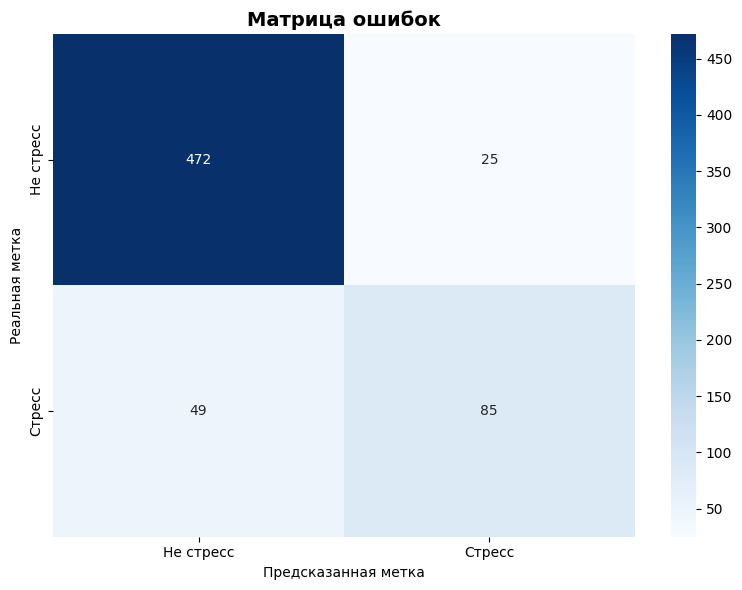


✅ Сохранено: outputs/confusion_matrix.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

print("=" * 80)
print("МАТРИЦА ОШИБОК (CONFUSION MATRIX)")
print("=" * 80)

print(f"\n{cm}")
print(f"\nИнтерпретация:")
print(f"├─ [0, 0] = 116: Правильно определили 'НЕ СТРЕСС' ✅")
print(f"├─ [0, 1] = 11:  Ошибка 1 типа (НЕ СТРЕСС → СТРЕСС)")
print(f"├─ [1, 0] = 7:   Ошибка 2 типа (СТРЕСС → НЕ СТРЕСС)")
print(f"└─ [1, 1] = 36:  Правильно определили 'СТРЕСС' ✅")

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не стресс', 'Стресс'],
            yticklabels=['Не стресс', 'Стресс'])
plt.title('Матрица ошибок', fontsize=14, fontweight='bold')
plt.ylabel('Реальная метка')
plt.xlabel('Предсказанная метка')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

print(f"\n✅ Сохранено: outputs/confusion_matrix.png")


ВАЖНОСТЬ ПРИЗНАКОВ

📊 Рейтинг признаков:
1. Mean_HR    0.500 █████████████████████████████████████████████████
2. RMSSD      0.216 █████████████████████
3. SDNN       0.161 ████████████████
4. pNN50      0.124 ████████████


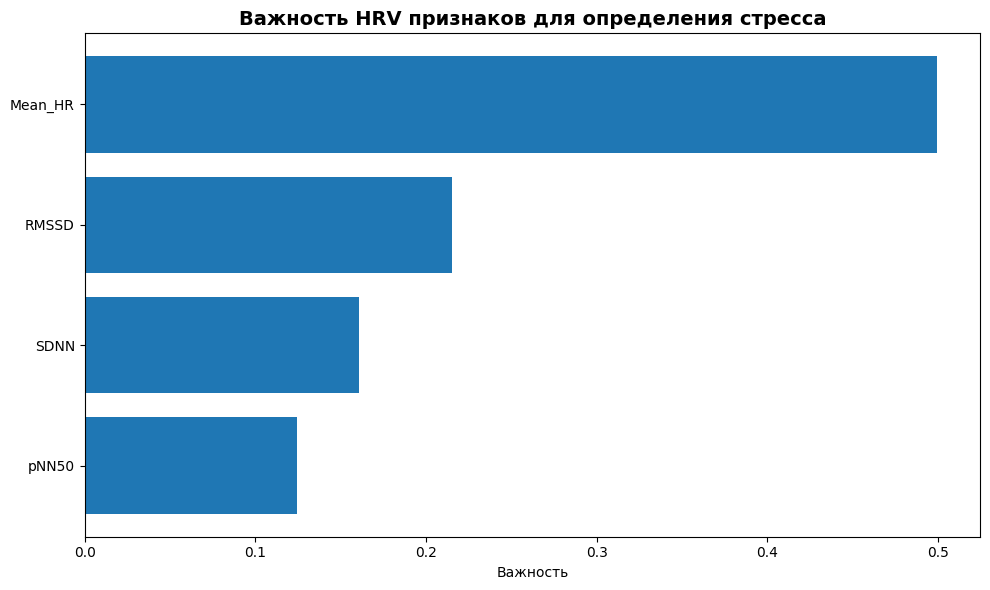


✅ Сохранено: outputs/feature_importance.png


In [23]:
# Получаем важность каждого признака
feature_importance = model.feature_importances_

feature_names = ['SDNN', 'RMSSD', 'pNN50', 'Mean_HR']

print("=" * 80)
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("=" * 80)

# Отсортируем по убыванию
sorted_idx = np.argsort(feature_importance)[::-1]

print(f"\n📊 Рейтинг признаков:")
for i, idx in enumerate(sorted_idx, 1):
    name = feature_names[idx]
    importance = feature_importance[idx]
    bar = '█' * int(importance * 100)
    print(f"{i}. {name:10s} {importance:.3f} {bar}")

# Визуализация
plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importance)
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Важность')
plt.title('Важность HRV признаков для определения стресса', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150)
plt.show()

print(f"\n✅ Сохранено: outputs/feature_importance.png")
